In [1]:
import xarray as xr
import numpy as np

In [95]:
import xarray as xr
from pathlib import Path

BASE_PATH = Path("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years")

def load_all_runs(file_name, var_name):
    paths = {
        "baseline": BASE_PATH / "baseline/output" / f"{file_name}.nc",
        "MM": BASE_PATH / "MM/output" / f"{file_name}.nc",
        "DM": BASE_PATH / "DM/output" / f"{file_name}.nc",
    }
    
    data = {
        key: xr.open_dataset(path)[var_name].sel(lon = slice(110,155), lat = slice(-40,-10))
        for key, path in paths.items()
    }
    
    return data

In [96]:
fpc = load_all_runs("fpc", "FPC")
# process function: skip total PFT (first), spatial mean
def process_fpc_per_pft(data):
    data['pft'] = data['pft'] - 2
    return data.sel(pft=slice(0, 7)).convert_calendar("standard").sel(time=slice("1969", "1979"))

# process all scenarios
fpc_proc = {name: process_fpc_per_pft(ds) for name, ds in fpc.items()}
fpc_proc

{'baseline': <xarray.DataArray 'FPC' (time: 132, pft: 8, lat: 300, lon: 450)> Size: 570MB
 [142560000 values with dtype=float32]
 Coordinates:
   * time     (time) datetime64[ns] 1kB 1969-01-16 1969-02-16 ... 1979-12-16
   * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
   * lat      (lat) float64 2kB -39.95 -39.85 -39.75 ... -10.25 -10.15 -10.05
   * lon      (lon) float64 4kB 110.1 110.2 110.2 110.4 ... 154.8 154.9 155.0
 Attributes:
     standard_name:  FPC
     long_name:      foliage projected cover,
 'MM': <xarray.DataArray 'FPC' (time: 132, pft: 8, lat: 300, lon: 450)> Size: 570MB
 [142560000 values with dtype=float32]
 Coordinates:
   * time     (time) datetime64[ns] 1kB 1969-01-16 1969-02-16 ... 1979-12-16
   * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
   * lat      (lat) float64 2kB -39.95 -39.85 -39.75 ... -10.25 -10.15 -10.05
   * lon      (lon) float64 4kB 110.1 110.2 110.2 110.4 ... 154.8 154.9 155.0
 Attributes:
     standard_name:  FPC
     long_name:      foliage projected c

In [97]:
fpc_proc['baseline']

<xarray.DataArray 'FPC' (time: 132, pft: 8, lat: 300, lon: 450)> Size: 570MB
[142560000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1kB 1969-01-16 1969-02-16 ... 1979-12-16
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 2kB -39.95 -39.85 -39.75 ... -10.25 -10.15 -10.05
  * lon      (lon) float64 4kB 110.1 110.2 110.2 110.4 ... 154.8 154.9 155.0
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

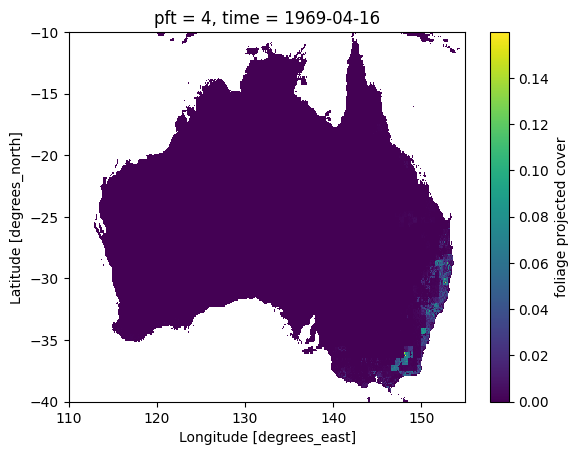

In [98]:
fpc_proc['baseline'][3,4].plot()

In [109]:
import numpy as np
import xarray as xr

FPC = fpc_proc['baseline'].where(fpc_proc['baseline'] > 1e-2)

def fit_tau(y):
    y = np.asarray(y)

    mask = np.isfinite(y) & (y > 0)
    if mask.sum() < 3:
        return np.nan

    t = np.arange(y.shape[0])

    slope, _ = np.polyfit(t[mask], np.log(y[mask]), 1)
    return -1 / slope

tau_base = xr.apply_ufunc(
    fit_tau,
    FPC,
    input_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)
tau_base

<xarray.DataArray 'FPC' (pft: 8, lat: 300, lon: 450)> Size: 9MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(8, 300, 450))
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 2kB -39.95 -39.85 -39.75 ... -10.25 -10.15 -10.05
  * lon      (lon) float64 4kB 110.1 110.2 110.2 110.4 ... 154.8 154.9 155.0
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [110]:
import numpy as np
import xarray as xr

DM = fpc_proc['DM'].where(fpc_proc['DM'] > 1e-2)

def fit_tau(y):
    y = np.asarray(y)

    mask = np.isfinite(y) & (y > 0)
    if mask.sum() < 3:
        return np.nan

    t = np.arange(y.shape[0])

    slope, _ = np.polyfit(t[mask], np.log(y[mask]), 1)
    return -1 / slope

tau_dm = xr.apply_ufunc(
    fit_tau,
    DM,
    input_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)
tau_dm

<xarray.DataArray 'FPC' (pft: 8, lat: 300, lon: 450)> Size: 9MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(8, 300, 450))
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 2kB -39.95 -39.85 -39.75 ... -10.25 -10.15 -10.05
  * lon      (lon) float64 4kB 110.1 110.2 110.2 110.4 ... 154.8 154.9 155.0
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

/scratch-local/77370/ipykernel_1005266/669393499.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


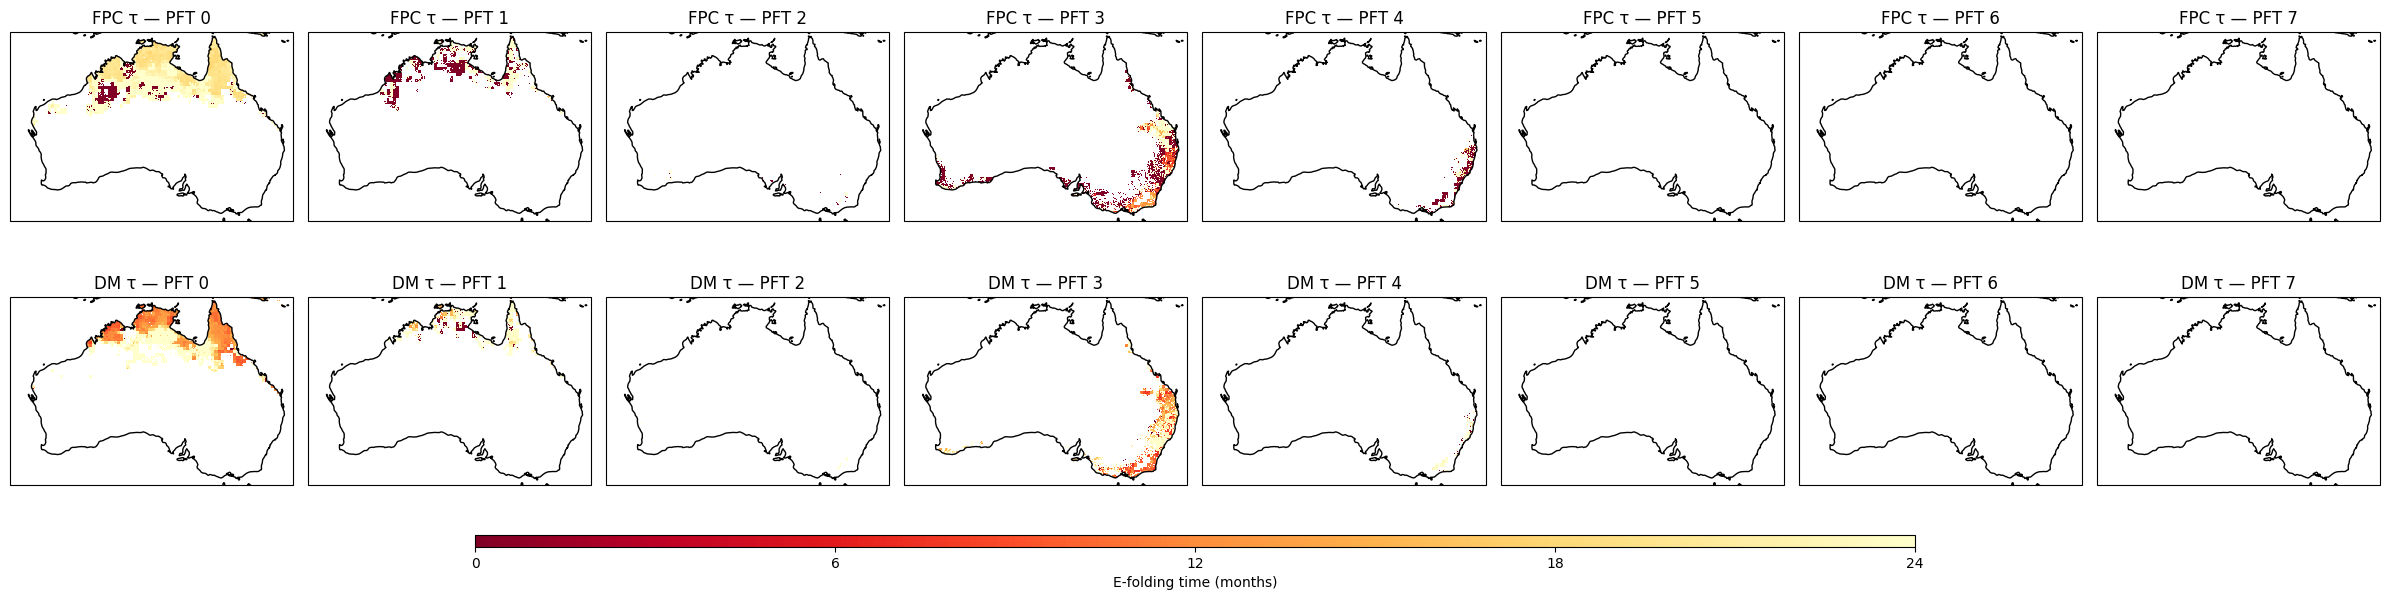

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

pfts = tau_base['pft'].values

nrows = 2
ncols = len(pfts)

vmin = 0
vmax = 24

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(3*ncols, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = np.atleast_2d(axes)

# ---------------------------
# TOP ROW: FPC (tau_base)
# ---------------------------
for i, p in enumerate(pfts):

    ax = axes[0, i]

    data = tau_base.sel(pft=p)

    im = ax.pcolormesh(
        tau_base['lon'],
        tau_base['lat'],
        data,
        transform=ccrs.PlateCarree(),
        shading='auto',
        vmin=vmin,
        vmax=vmax,
        cmap="YlOrRd_r"
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    ax.set_title(f'FPC τ — PFT {p}')

# ---------------------------
# BOTTOM ROW: DM
# ---------------------------
for i, p in enumerate(pfts):

    ax = axes[1, i]

    data = tau_dm.sel(pft=p)

    im = ax.pcolormesh(
        tau_dm['lon'],
        tau_dm['lat'],
        data,
        transform=ccrs.PlateCarree(),
        shading='auto',
        vmin=vmin,
        vmax=vmax,
        cmap="YlOrRd_r"
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    ax.set_title(f'DM τ — PFT {p}')

# ---------------------------
# shared colorbar
# ---------------------------
cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')

cbar.set_label('E-folding time (months)')
cbar.set_ticks([0, 6, 12, 18, 24])

plt.tight_layout()
plt.show()

In [115]:
mask = xr.open_dataset("/projects/prjs2023/chapter3/remapped_masks/mask_CAL_0_1_degrees.nc").Band1
mask

<xarray.DataArray 'Band1' (lat: 1800, lon: 3600)> Size: 52MB
[6480000 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0

In [75]:
ds = xr.open_dataset("/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/tau_baseline.nc").__xarray_dataarray_variable__
ds

<xarray.DataArray '__xarray_dataarray_variable__' (pft: 8, lat: 1397, lon: 3600)> Size: 322MB
[40233600 values with dtype=float64]
Coordinates:
  * pft      (pft) int32 32B 2 3 4 5 6 7 8 9
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T

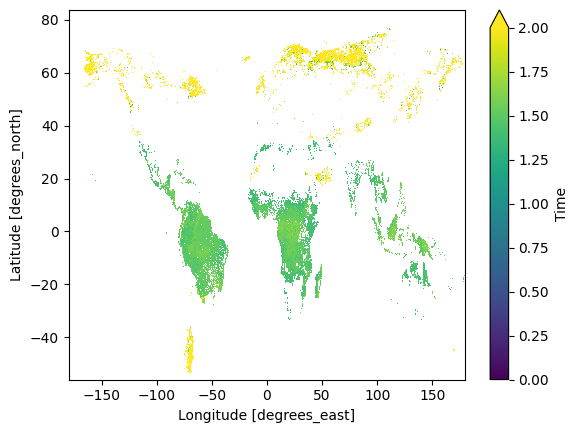

In [86]:
ds_mean = ds.where(ds < 20).where(ds > 0).mean(dim = 'pft')
ds_mean.plot(vmin = 0, vmax = 2)

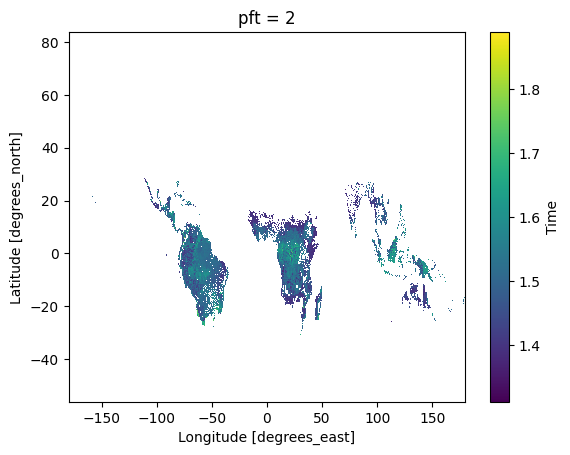

In [77]:
ds[0].plot()

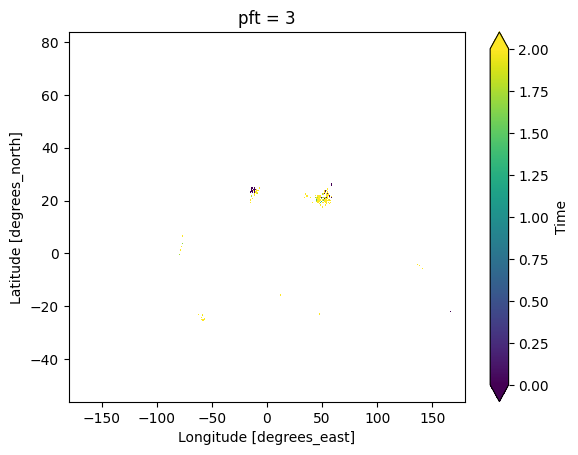

In [79]:
ds[1].plot(vmin = 0, vmax = 2)

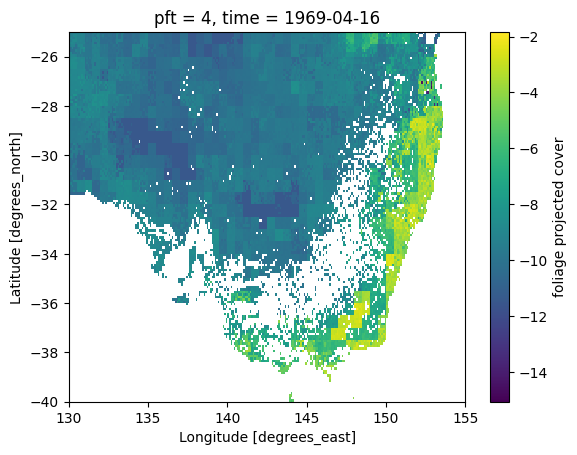

In [ ]:
import numpy as np
import xarray as xr


# avoid log(0)
FPC = fpc_proc['baseline'].where(fpc_proc['baseline'] > 0)

logFPC = np.log(FPC)


# # convert time to numeric (years)
# t = xr.DataArray(
#     (FPC['time'].dt.year + FPC['time'].dt.dayofyear / 365.0),
#     dims="time"
# )

# # subtract first time to avoid big numbers
# t = t - t.isel(time=0)

# linear regression: slope = -k
slope = xr.apply_ufunc(
    lambda x, y: np.polyfit(x, y, 1)[0],
    t, logFPC,
    input_core_dims=[["time"], ["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float]
)

# k = -slope
# tau = 1 / k   # e-folding time



In [31]:
import numpy as np
import xarray as xr

def compute_efolding(FPC):
    # avoid log(0)
    FPC = FPC.where(FPC > 0)

    logFPC = np.log(FPC)

    # convert time to numeric (years)
    t = xr.DataArray(
        (FPC['time'].dt.year + FPC['time'].dt.dayofyear / 365.0),
        dims="time"
    )

    # subtract first time to avoid big numbers
    t = t - t.isel(time=0)

    # linear regression: slope = -k
    slope = xr.apply_ufunc(
        lambda x, y: np.polyfit(x, y, 1)[0],
        t, logFPC,
        input_core_dims=[["time"], ["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float]
    )

    k = -slope
    tau = 1 / k   # e-folding time

    return tau

In [48]:
tau_base = compute_efolding(fpc_proc['baseline'])
tau_base

<xarray.DataArray (pft: 8, lat: 150, lon: 250)> Size: 2MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(8, 150, 250))
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 1kB -39.95 -39.85 -39.75 ... -25.25 -25.15 -25.05
  * lon      (lon) float64 2kB 130.1 130.2 130.3 130.4 ... 154.8 154.9 155.0
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T

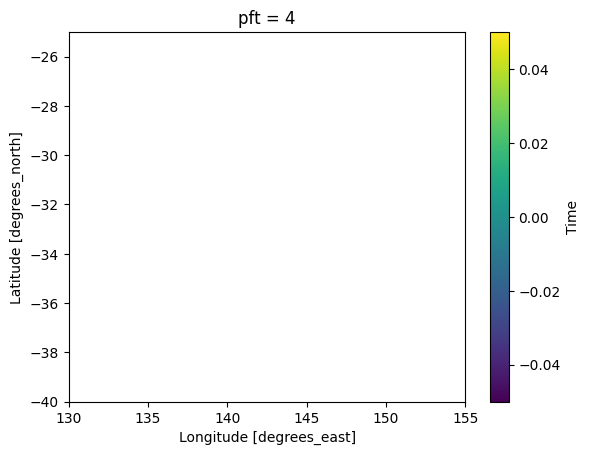

In [50]:
tau_base[4].plot()

In [49]:
tau_DM   = compute_efolding(fpc_proc['DM'])
tau_DM

<xarray.DataArray (pft: 8, lat: 150, lon: 250)> Size: 2MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(8, 150, 250))
Coordinates:
  * pft      (pft) int32 32B 0 1 2 3 4 5 6 7
  * lat      (lat) float64 1kB -39.95 -39.85 -39.75 ... -25.25 -25.15 -25.05
  * lon      (lon) float64 2kB 130.1 130.2 130.3 130.4 ... 154.8 154.9 155.0
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T

In [34]:
valid_pfts = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree",
]

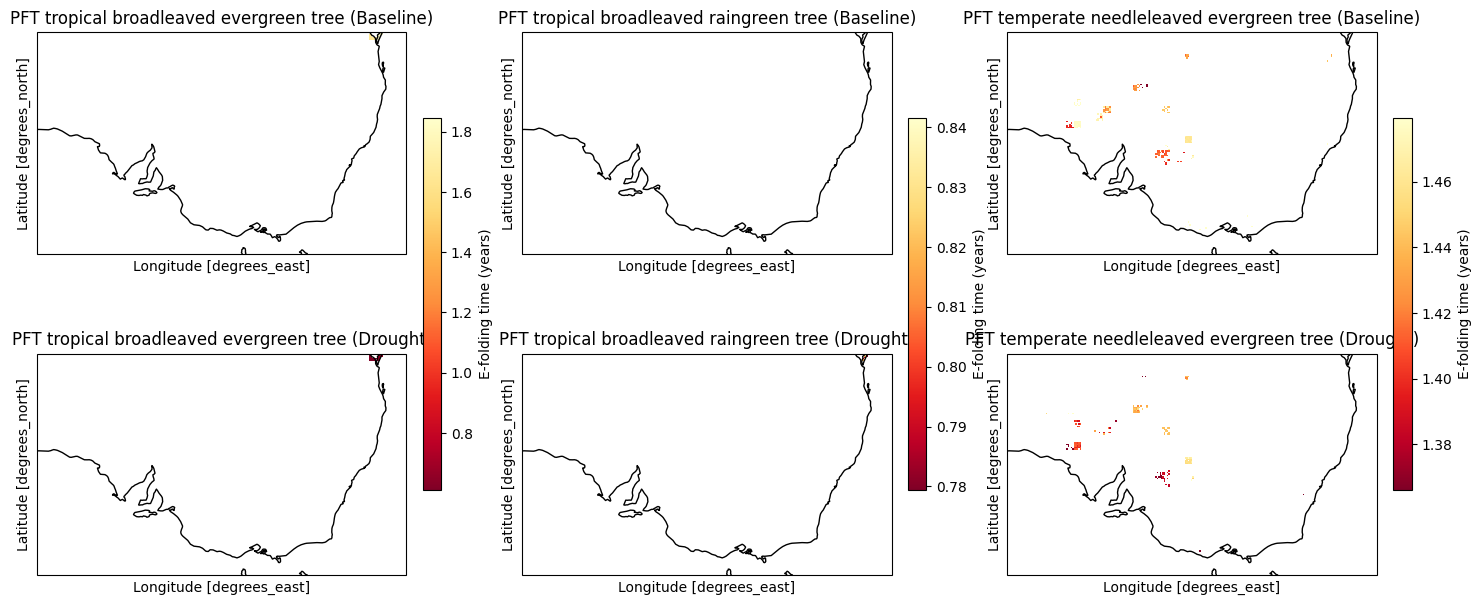

In [35]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

def plot_pft_comparison_autoscale(tau_base, tau_DM, valid_pfts):
    n = len(valid_pfts)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))

    fig = plt.figure(figsize=(6*ncols, 8*nrows))

    for i, pft in enumerate(valid_pfts):
        row = i // ncols
        col = i % ncols
        
        base = tau_base.sel(pft=i)
        dm   = tau_DM.sel(pft=i)

        # --- compute shared vmin/vmax for THIS PFT ---
        combined = np.concatenate([
            base.values.flatten(),
            dm.values.flatten()
        ])

        combined = combined[np.isfinite(combined)]

        if len(combined) == 0:
            continue

        # robust scaling (avoids outliers blowing up colorbar)
        vmin = np.percentile(combined, 5)
        vmax = np.percentile(combined, 95)

        # --- TOP: baseline ---
        ax_top = plt.subplot(
            2*nrows, ncols, 2*row*ncols + col + 1,
            projection=ccrs.PlateCarree()
        )

        im = base.plot(
            ax=ax_top,
            transform=ccrs.PlateCarree(),
            cmap="YlOrRd_r",
            vmin=vmin, vmax=vmax,
            add_colorbar=False
        )

        ax_top.coastlines()
        ax_top.set_title(f"PFT {pft} (Baseline)")
        ax_top.set_xticks([])
        ax_top.set_yticks([])

        # --- BOTTOM: drought ---
        ax_bot = plt.subplot(
            2*nrows, ncols, (2*row+1)*ncols + col + 1,
            projection=ccrs.PlateCarree()
        )

        dm.plot(
            ax=ax_bot,
            transform=ccrs.PlateCarree(),
            cmap="YlOrRd_r",
            vmin=vmin, vmax=vmax,
            add_colorbar=False
        )

        ax_bot.coastlines()
        ax_bot.set_title(f"PFT {pft} (Drought)")
        ax_bot.set_xticks([])
        ax_bot.set_yticks([])

        # --- shared colorbar per PFT ---
        cbar = fig.colorbar(
            im,
            ax=[ax_top, ax_bot],
            orientation="vertical",
            fraction=0.046,
            pad=0.04
        )
        cbar.set_label("E-folding time (years)")

    #plt.tight_layout()
    plt.show()
    
plot_pft_comparison_autoscale(tau_base, tau_DM, valid_pfts)

In [ ]:
gpp = load_all_runs("pft_gpp", "GPP")

def process_gpp_per_pft(data):
    return data.sel(pft=slice(1, 12)).convert_calendar("standard")

# process all scenarios automatically
gpp_proc = {name: process_gpp_per_pft(ds) for name, ds in gpp.items()}
gpp_proc

In [ ]:
valid_pfts = []
for pft in list(gpp_proc.values())[0].pft.values:
    combined = np.concatenate([
        gpp_proc[name].sel(pft=pft).values for name in gpp_proc
    ])
    
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

In [ ]:
gpp = load_all_runs("pft_gpp", "GPP")

In [ ]:
fpc = load_all_runs("fpc", "FPC")

baseline_nodrought_FPC = fpc["baseline_nodrought"]
DM_nodrought_FPC = fpc["DM_nodrought"]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def process_gpp_per_pft(data):
    return data.sel(pft=slice(1, 12)).convert_calendar("standard")

# process all scenarios automatically
gpp_proc = {name: process_gpp_per_pft(ds) for name, ds in gpp.items()}

# find valid PFTs
valid_pfts = []
for pft in list(gpp_proc.values())[0].pft.values:
    combined = np.concatenate([
        gpp_proc[name].sel(pft=pft).values for name in gpp_proc
    ])
    
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

# create subplots dynamically
n = len(valid_pfts)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n), sharex=True)
axes = np.atleast_1d(axes)

for i, pft in enumerate(valid_pfts):
    ax = axes[i]

    for name, data in gpp_proc.items():
        if name.endswith("nodrought"):
            linestyle = "-"      # solid for no drought
        elif name.endswith("drought"):
            linestyle = "--"     # dashed for drought
        else:
            linestyle = "-"      # fallback
        ax.plot(data.time, data.sel(pft=pft), linestyle=linestyle, label=name)

    ax.set_title(f"PFT {pft}", loc="left")
    ax.grid(alpha=0.3)

# labels
fig.supxlabel("Time")
fig.supylabel("GPP (gC/m²/month)")
fig.suptitle("GPP per active PFT (1–12), Spatial Mean")

# legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load FPC for all scenarios
fpc = load_all_runs("fpc", "FPC")

# process function: skip total PFT (first), spatial mean
def process_fpc_per_pft(data):
    return data.sel(pft=slice(2, 12)).convert_calendar("standard")

# process all scenarios
fpc_proc = {name: process_fpc_per_pft(ds) for name, ds in fpc.items()}

# determine valid PFTs (non-empty)
valid_pfts = []
for pft in list(fpc_proc.values())[0].pft.values:
    combined = np.concatenate([fpc_proc[name].sel(pft=pft).values for name in fpc_proc])
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

# create dynamic vertical subplots
n = len(valid_pfts)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n), sharex=True)
axes = np.atleast_1d(axes)

for i, pft in enumerate(valid_pfts):
    ax = axes[i]
    
    for name, data in fpc_proc.items():
        if name.endswith("nodrought"):
            linestyle = "-"      # solid for no drought
        elif name.endswith("drought"):
            linestyle = "--"     # dashed for drought
        else:
            linestyle = "-"      # fallback
        ax.plot(data.time, data.sel(pft=pft), linestyle=linestyle, label=name)
    
    ax.set_title(f"PFT {pft - 1}", loc="left")  # subtract 1 because we skipped the total
    ax.grid(alpha=0.3)

# labels and title
fig.supxlabel("Time")
fig.supylabel("FPC")
fig.suptitle("FPC per active PFT (2–12), Spatial Mean (skipping total)")

# legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load NIND for all scenarios
nind = load_all_runs("pft_nind", "nind")

# processing function: first 12 PFTs, spatial mean
def process_nind_per_pft(data):
    return data.sel(pft=slice(1, 12)).convert_calendar("standard")

# process all scenarios
nind_proc = {}
for name, ds in nind.items():
    proc = process_nind_per_pft(ds)
    
    # if baseline runs, sum monthly -> yearly
    if "baseline" in name:
        proc = proc.resample(time="YS").sum()
    
    nind_proc[name] = proc

# determine valid PFTs (non-empty)
valid_pfts = []
for pft in list(nind_proc.values())[0].pft.values:
    combined = np.concatenate([nind_proc[name].sel(pft=pft).values for name in nind_proc])
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

# create vertical subplots dynamically
n = len(valid_pfts)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n), sharex=True)
axes = np.atleast_1d(axes)

for i, pft in enumerate(valid_pfts):
    ax = axes[i]
    
    for name, data in nind_proc.items():
        # precise linestyle: solid = no drought, dashed = drought
        if name.endswith("nodrought"):
            linestyle = "-"
        elif name.endswith("drought"):
            linestyle = "--"
        else:
            linestyle = "-"
        ax.plot(data.time, data.sel(pft=pft), linestyle=linestyle, label=name)
    
    ax.set_title(f"PFT {pft}", loc="left")
    ax.grid(alpha=0.3)

# labels and title
fig.supxlabel("Time")
fig.supylabel("NIND")
fig.suptitle("NIND per active PFT (1–12), Spatial Mean")

# legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
valid_pfts = []
for pft in list(gpp_proc.values())[0].pft.values:
    combined = np.concatenate([
        gpp_proc[name].sel(pft=pft).values for name in gpp_proc
    ])
    
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

runs = list(gpp_proc.keys())

pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree',
    'Tropical C4 grass',
    'Temperate C3 grass',
    'Polar C3 grass'
]

all_pfts = nind_proc[list(nind_proc.keys())[0]].pft.values

# map each PFT value to its name based on position
pft_labels = {
    pft: pft_names[int(pft) - 1]
    for pft in all_pfts
}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [1, 2]
temperate = [3, 4, 5]
boreal = [6, 7, 8]
grass = [9, 10, 11]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

selected_runs = runs[3:6]  # pick exactly 3 runs

for ax, run in zip(axes, selected_runs):
    data = gpp_proc[run]
    
    years = data.time.values
    
    # collect data per PFT
    stack_data = []
    labels = []
    colors = []
    
    for pft in valid_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)
        labels.append(pft_labels[pft])
        colors.append(pft_colors[pft])
    
    # stacked area plot
    ax.stackplot(years, stack_data, labels=labels, colors=colors)
    
    ax.set_title(run, loc="left")
    ax.set_ylabel("GPP")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 175)  

# shared x-label
axes[-1].set_xlabel("Year")

# legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

runs = list(nind_proc.keys())

pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree',
    'Tropical C4 grass',
    'Temperate C3 grass',
    'Polar C3 grass'
]

all_pfts = nind_proc[list(nind_proc.keys())[0]].pft.values

# map each PFT value to its name based on position
pft_labels = {
    pft: pft_names[int(pft) - 1]
    for pft in all_pfts
}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [1, 2]
temperate = [3, 4, 5]
boreal = [6, 7, 8]
grass = [9, 10, 11]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

selected_runs = runs[3:6]  # pick exactly 3 runs

for ax, run in zip(axes, selected_runs):
    data = nind_proc[run]
    
    years = data.time.values
    
    # collect data per PFT
    stack_data = []
    labels = []
    colors = []
    
    for pft in valid_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)
        labels.append(pft_labels[pft])
        colors.append(pft_colors[pft])
    
    # stacked area plot
    ax.stackplot(years, stack_data, labels=labels, colors=colors)
    
    ax.set_title(run, loc="left")
    ax.set_ylabel("NIND")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 2.5)

# shared x-label
axes[-1].set_xlabel("Year")

# legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

runs = list(fpc_proc.keys())

pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree',
    'Tropical C4 grass',
    'Temperate C3 grass',
    'Polar C3 grass'
]

all_pfts = fpc_proc[list(fpc_proc.keys())[0]].pft.values

# map each PFT value to its name based on position
pft_labels = {
    pft: pft_names[int(pft) - 2]
    for pft in all_pfts
}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [2, 3]
temperate = [4, 5, 6]
boreal = [7, 8, 9]
grass = [10, 11, 12]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

selected_runs = runs[3:6]  # pick exactly 3 runs

for ax, run in zip(axes, selected_runs):
    data = fpc_proc[run]
    
    years = data.time.values
    
    # collect data per PFT
    stack_data = []
    labels = []
    colors = []
    
    for pft in valid_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)
        labels.append(pft_labels[pft])
        colors.append(pft_colors[pft])
    
    # stacked area plot
    ax.stackplot(years, stack_data, labels=labels, colors=colors)
    
    ax.set_title(run, loc="left")
    ax.set_ylabel("FPC")
    ax.grid(alpha=0.3)

# shared x-label
axes[-1].set_xlabel("Year")

# legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig(
    "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_07_drought_experiment/10years/2026_04_20_tenyeardrought_FPC.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.show()